### MULTIII Kalasss Klasscification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000','#0000FF'])
cmap_ligt = ListedColormap(['#FFBBBB','#BBBBFF'])

### Utils

In [3]:
def softmax(H):
    return (np.exp(H.T)/np.sum(np.exp(H),axis=1)).T

def cat_cross_entropy(Y,P_hat):
    return -(1/len(Y)) * np.sum(np.sum(Y*np.log(P_hat),axis=1),axis=0)

def indices_to_one_hot(data, nb_classes):
    targets = np.array(data).reshape(-1)
    return np.eye(nb_classes)[targets]

def accuracy(y,y_hat):
    return np.mean(y==y_hat)
                   
def confusion_matrix(y,y_hat):
    plt.figure(figsize=(10,7))
    y_actu = pd.Series(y, name='Actual')
    y_pred = pd.Series(y_hat, name='Predicted')
    cm = pd.crosstab(y_actu, y_pred)
    ax = sns.heatmap(cm, annot=True, fmt="d")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


In [4]:
df_train = pd.read_csv("../../dataset/day20/TripGaussKNN.csv",index_col=0)
X_df = df_train.iloc[:,0:2]
y_df = df_train.iloc[:,2]

In [5]:
X = X_df.to_numpy()
y = y_df.to_numpy()

### Logistic Reg

In [6]:
class MVLogisticRegression():

    def fit(self, X, y, eta=1e-3, epochs=1e3, show_curve=True):
        epochs = int(epochs)
        N, D = X.shape

        K = len(np.unique(y))
        Y = indices_to_one_hot(y,K).astype(int)

        # Random Initialization for Weights and Biases
        self.W = np.random.randn(D,K)
        self.B = np.random.randn(K)

        # Build Container for Loss
        J = np.zeros(epochs)

        # Gradient Descent
        for epoch in range(epochs):
            P_hat = self.__forward__(X)
            J[epoch] = cat_cross_entropy(Y,P_hat)
            # Update the Weights
            self.W -= eta * (1/N) * X.T@(P_hat-Y)
            self.B -= eta*(1/N)*np.sum(P_hat-Y,axis=0)
        
        # Show Learning Curve
        if show_curve:
            plt.figure()
            plt.plot(J)
            plt.xlabel("epochs")
            plt.ylabel(r"$\mathcal{J}$")
            plt.title("Training Curse")
    
    def __forward__(self,X):
        return softmax(X@self.W+self.B)
    
    def predict(self,X):
        return np.argmax(self.__forward__(X), axis=1)

In [7]:
mvlog = MVLogisticRegression()

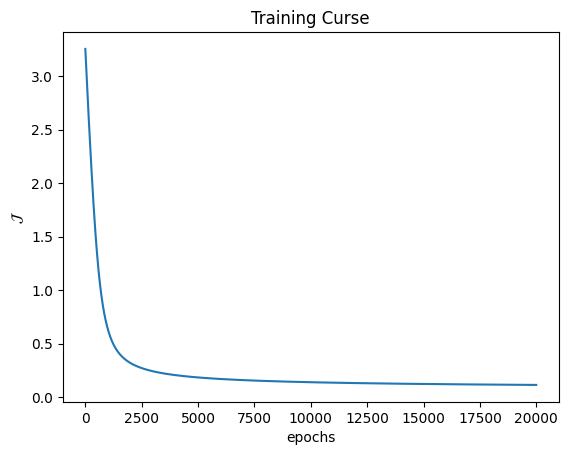

In [8]:
mvlog.fit(X,y,eta=1e-3,epochs=2e4)

In [9]:
y_hat = mvlog.predict(X)

In [10]:
print(accuracy(y,y_hat))

0.9666666666666667
